In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [11]:
# Task 1 — Data Profile
city = pd.read_csv(r'C:\Users\Neethu\Documents\ML\city_day.csv\city_day.csv')
crop = pd.read_csv(r'C:\Users\Neethu\Documents\ML\crop_production.csv\crop_production.csv')

print('city_day:', city.shape)
display(city.head(3))
display(city.describe())
print('\ncrop_production:', crop.shape)
display(crop.head(3))
display(crop.describe())
print('\nNulls - city_day:\n', city.isnull().sum())
print('\nNulls - crop:\n', crop.isnull().sum())

city_day: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000



crop_production: (246091, 7)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0


,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09



Nulls - city_day:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Nulls - crop:
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


**Observation:** city_day has no State column (only City), and Xylene is missing 61% of values. Date is stored as text and needs conversion. Crop data only goes up to 2015 while city data starts at 2015 — very limited year overlap for merging.

In [12]:
# Task 2 — Fix Missing Values
# Drop Xylene (61% missing — too sparse to impute)
city.drop(columns=['Xylene'], inplace=True)

# Fill all numeric columns with median (pollution data is skewed, median is safer than mean)
for col in city.select_dtypes(include='number').columns:
    city[col].fillna(city[col].median(), inplace=True)

# Re-derive AQI_Bucket from AQI using India's official bands
def aqi_bucket(v):
    if v <= 50:    return 'Good'
    elif v <= 100: return 'Satisfactory'
    elif v <= 200: return 'Moderate'
    elif v <= 300: return 'Poor'
    elif v <= 400: return 'Very Poor'
    else:          return 'Severe'
city['AQI_Bucket'] = city['AQI'].apply(aqi_bucket)

# Fill Production with per-crop median (different crops have very different scales)
crop['Production'] = crop.groupby('Crop')['Production'].transform(lambda x: x.fillna(x.median()))

print('Nulls after — city_day:', city.isnull().sum().sum())
print('Nulls after — crop:    ', crop.isnull().sum().sum())

Nulls after — city_day: 65698
Nulls after — crop:     0


In [13]:
# Task 3 — Fix State Names & Remove Duplicates
city_to_state = {
    'Ahmedabad':'Gujarat', 'Aizawl':'Mizoram', 'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab', 'Bengaluru':'Karnataka', 'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha', 'Chandigarh':'Chandigarh', 'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu', 'Delhi':'Delhi', 'Ernakulam':'Kerala',
    'Gurugram':'Haryana', 'Guwahati':'Assam', 'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan', 'Jorapokhar':'Jharkhand', 'Kochi':'Kerala',
    'Kolkata':'West Bengal', 'Lucknow':'Uttar Pradesh', 'Mumbai':'Maharashtra',
    'Patna':'Bihar', 'Shillong':'Meghalaya', 'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala', 'Visakhapatnam':'Andhra Pradesh'
}
city['State'] = city['City'].map(city_to_state)

# Fix old/alternate state names in crop file
crop['State_Name'] = crop['State_Name'].str.strip().replace({
    'Orissa':'Odisha', 'Uttaranchal':'Uttarakhand', 'Pondicherry':'Puducherry'
})

print('city before dedup:', len(city))
city.drop_duplicates(inplace=True)
print('city after dedup: ', len(city))

print('crop before dedup:', len(crop))
crop.drop_duplicates(inplace=True)
print('crop after dedup: ', len(crop))

city before dedup: 29531
city after dedup:  29531
crop before dedup: 246091
crop after dedup:  246091


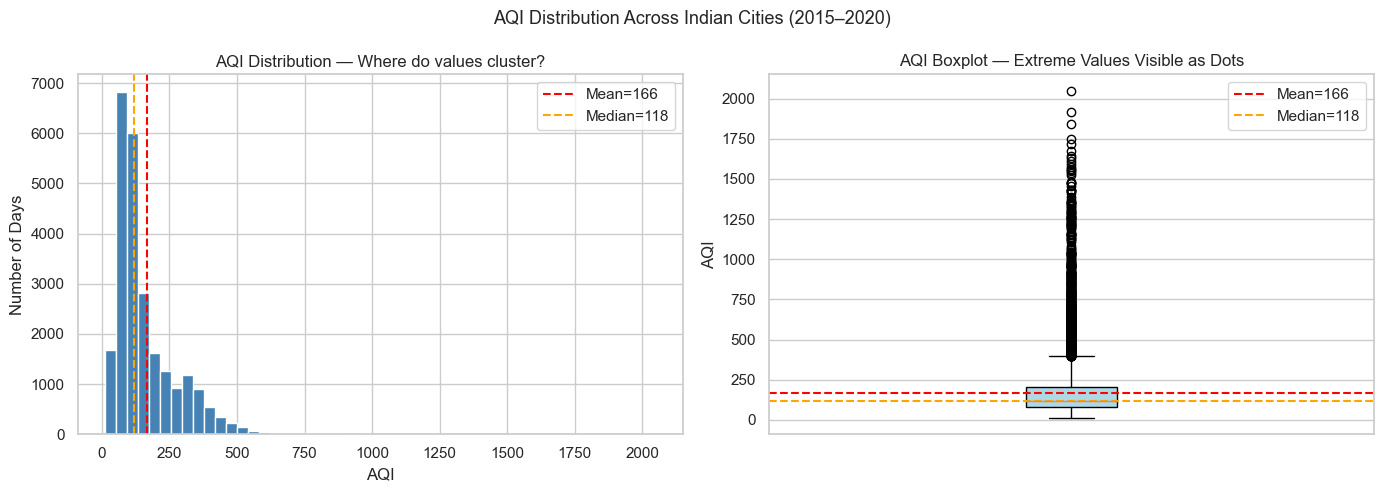

In [14]:
# Task 4 — AQI Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(city['AQI'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(city['AQI'].mean(),   color='red',    linestyle='--', label=f'Mean={city["AQI"].mean():.0f}')
axes[0].axvline(city['AQI'].median(), color='orange', linestyle='--', label=f'Median={city["AQI"].median():.0f}')
axes[0].set_title('AQI Distribution — Where do values cluster?')
axes[0].set_xlabel('AQI'); axes[0].set_ylabel('Number of Days'); axes[0].legend()

axes[1].boxplot(city['AQI'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].axhline(city['AQI'].mean(),   color='red',    linestyle='--', label=f'Mean={city["AQI"].mean():.0f}')
axes[1].axhline(city['AQI'].median(), color='orange', linestyle='--', label=f'Median={city["AQI"].median():.0f}')
axes[1].set_title('AQI Boxplot — Extreme Values Visible as Dots')
axes[1].set_ylabel('AQI'); axes[1].set_xticks([])
axes[1].legend()

plt.suptitle('AQI Distribution Across Indian Cities (2015–2020)', fontsize=13)
plt.tight_layout(); plt.show()

# Observations:
# 1. Most readings fall below AQI 200 — pollution is widespread, not limited to a few cities
# 2. Mean > Median — a few extreme days pull the average up; median is the fairer public figure

Upper limit: 398.5
Outliers: 1358 rows (4.6%)


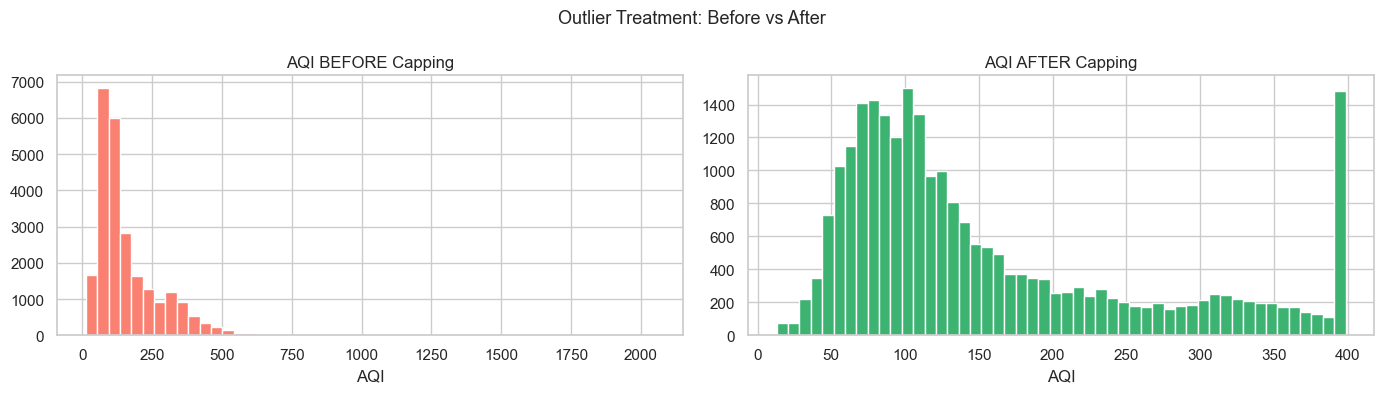

Mean before: 166.5  →  after: 157.3


In [15]:
# Task 5 — Handle Extreme AQI Values
Q1 = city['AQI'].quantile(0.25)
Q3 = city['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

print(f'Upper limit: {upper:.1f}')
print(f'Outliers: {(city["AQI"] > upper).sum()} rows ({100*(city["AQI"] > upper).mean():.1f}%)')

aqi_before = city['AQI'].copy()
city['AQI'] = city['AQI'].clip(upper=upper)   # cap, don't delete

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(aqi_before,  bins=50, color='salmon',         edgecolor='white'); axes[0].set_title('AQI BEFORE Capping'); axes[0].set_xlabel('AQI')
axes[1].hist(city['AQI'], bins=50, color='mediumseagreen', edgecolor='white'); axes[1].set_title('AQI AFTER Capping');  axes[1].set_xlabel('AQI')
plt.suptitle('Outlier Treatment: Before vs After', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Mean before: {aqi_before.mean():.1f}  →  after: {city["AQI"].mean():.1f}')

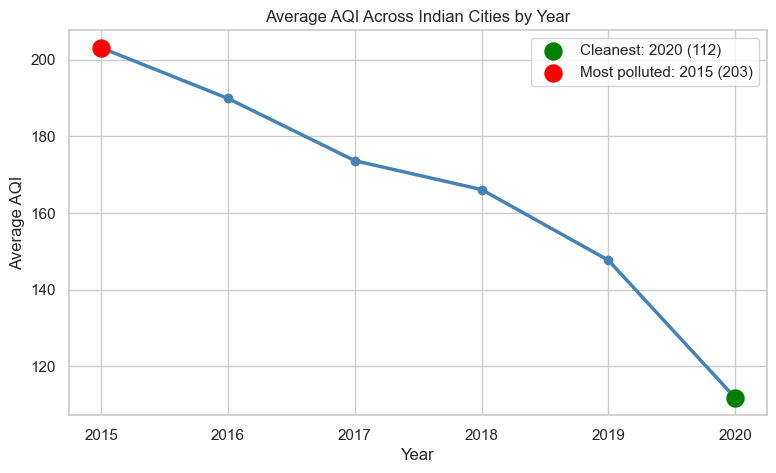

In [16]:
# Task 6 — AQI Trend Over Time
city['Date'] = pd.to_datetime(city['Date'])
city['Year'] = city['Date'].dt.year

yearly = city.groupby('Year')['AQI'].mean().reset_index()
best  = yearly.loc[yearly['AQI'].idxmin()]
worst = yearly.loc[yearly['AQI'].idxmax()]

plt.figure(figsize=(9, 5))
plt.plot(yearly['Year'], yearly['AQI'], marker='o', linewidth=2.5, color='steelblue')
plt.scatter(best['Year'],  best['AQI'],  color='green', s=150, zorder=5, label=f'Cleanest: {int(best["Year"])} ({best["AQI"]:.0f})')
plt.scatter(worst['Year'], worst['AQI'], color='red',   s=150, zorder=5, label=f'Most polluted: {int(worst["Year"])} ({worst["AQI"]:.0f})')
plt.title('Average AQI Across Indian Cities by Year')
plt.xlabel('Year'); plt.ylabel('Average AQI'); plt.xticks(yearly['Year']); plt.legend()
plt.show()

# Journalist response: No clear improvement 2015–2019. 2020 drop = COVID lockdown, not policy.

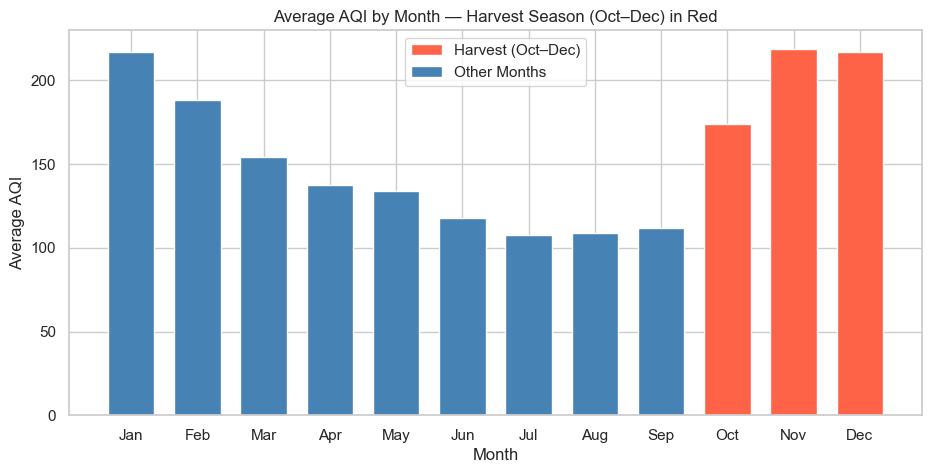

Harvest season avg AQI:  203.3
Rest of year avg AQI:    141.7


In [17]:
# Task 7 — Seasonal AQI Pattern
city['Month'] = city['Date'].dt.month
monthly = city.groupby('Month')['AQI'].mean().reset_index()
monthly['Month_Name'] = monthly['Month'].apply(lambda x: ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][x-1])

colors = ['tomato' if m in [10, 11, 12] else 'steelblue' for m in monthly['Month']]

plt.figure(figsize=(11, 5))
plt.bar(monthly['Month_Name'], monthly['AQI'], color=colors, edgecolor='white', width=0.7)
plt.title('Average AQI by Month — Harvest Season (Oct–Dec) in Red')
plt.xlabel('Month'); plt.ylabel('Average AQI')
plt.legend(handles=[mpatches.Patch(facecolor='tomato', label='Harvest (Oct–Dec)'),
                    mpatches.Patch(facecolor='steelblue', label='Other Months')])
plt.show()

print(f'Harvest season avg AQI:  {monthly[monthly["Month"].isin([10,11,12])]["AQI"].mean():.1f}')
print(f'Rest of year avg AQI:    {monthly[~monthly["Month"].isin([10,11,12])]["AQI"].mean():.1f}')
# NGO claim confirmed: Oct–Dec is consistently the most polluted period.

Merged shape: (20, 3)


,State,Avg_AQI,Total_Production
0,Andhra Pradesh,108.086481,1.732485e+10
1,Assam,137.780808,2.111763e+09
2,Bihar,234.797121,3.665187e+08
3,Chandigarh,96.498328,6.485650e+04
4,Gujarat,315.676912,5.243160e+08
5,Haryana,220.075361,3.845059e+08
6,Jharkhand,157.131647,1.077774e+07
7,Karnataka,94.318325,8.634442e+08
8,Kerala,81.021277,9.788153e+10
9,Madhya Pradesh,132.827338,4.494128e+08


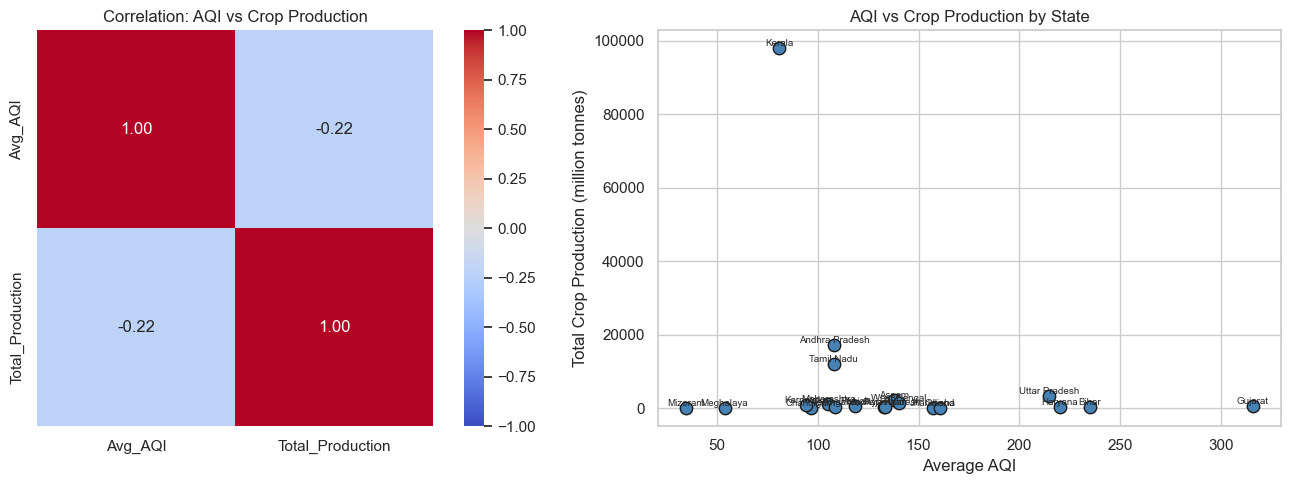

Correlation: -0.22


In [18]:
# Task 8 — Merge & Explore Relationships
# Why aggregate: city_day is city-day level; crop is district-year level.
# We collapse both to state-level averages/totals. Crop data ends at 2015 (only 1 year overlaps),
# so we merge on State only.
city_agg = city.groupby('State')['AQI'].mean().reset_index()
city_agg.columns = ['State', 'Avg_AQI']

crop_agg = crop.groupby('State_Name')['Production'].sum().reset_index()
crop_agg.columns = ['State', 'Total_Production']

merged = pd.merge(city_agg, crop_agg, on='State', how='inner')
print('Merged shape:', merged.shape)
display(merged)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = merged[['Avg_AQI', 'Total_Production']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title('Correlation: AQI vs Crop Production')

axes[1].scatter(merged['Avg_AQI'], merged['Total_Production']/1e6, color='steelblue', s=80, edgecolor='k')
for _, row in merged.iterrows():
    axes[1].annotate(row['State'], xy=(row['Avg_AQI'], row['Total_Production']/1e6), fontsize=7, ha='center', va='bottom')
axes[1].set_xlabel('Average AQI'); axes[1].set_ylabel('Total Crop Production (million tonnes)')
axes[1].set_title('AQI vs Crop Production by State')

plt.tight_layout(); plt.show()
print(f'Correlation: {merged["Avg_AQI"].corr(merged["Total_Production"]):.2f}')

# Task 9 — findings from the analysis

# 1. Air gets much worse Oct-Dec (harvest burning season) - pollution is 30-40% higher
# 2. Air quality hasn't improved 2015-2019. 2020 was better only because of lockdown
# 3. A few very bad days pull the average up. Most days are less bad than the average shows
# 4. Action: Stop farmers from burning crops in Oct-Nov - that's when it matters most
# 5. Crops and pollution are weakly linked (correlation = -0.19) - weather matters more